# Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam.multicam import MultiCAM, MultiCamSampling
from multicam.qt import qt, qt_gauss
from multicam_tng.multicam2 import multicam_new_prediction_repeats
from scipy.stats import spearmanr

from multicam_tng.utils import get_an_from_mpeak_mah, generate_randoms
from astropy.table import Table
from scipy.stats import spearmanr


from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife, tpcf


In [2]:
# this is just metadata which sims share
metadata = pd.read_csv("../../data/tng300-1-table.csv")
redshift_snaps = metadata["Redshift"].values
scales = 1 / (1 + redshift_snaps)
scales.shape

(100,)

In [3]:
# load data
_hydro_raw = Table.read("../../data/hydro_final.ecsv")
flag = _hydro_raw["SubhaloFlag"]
hydro_raw = _hydro_raw[flag == 1]
len(hydro_raw)

101364

In [4]:
# Add z12
hydro_raw["z12"] = (1 / hydro_raw["a12"]) - 1

In [5]:
# apply lower cut on mpeak (resolution) only and use this catalog for SHAM application
log_mpeak = np.log10(hydro_raw["mpeak"])
mpeak_cut_mask = log_mpeak > 11
hydro_high = hydro_raw[mpeak_cut_mask]
len(hydro_high)

12652

In [6]:
# sham application
x = np.log10(hydro_high["mpeak"].data)
y = np.log10(hydro_high["stellar_mass"].data)
logmstar_sham_high = qt(x, y)
logmstar_sham_high.shape

(12652,)

Text(0.5, 1.0, 'SHMR')

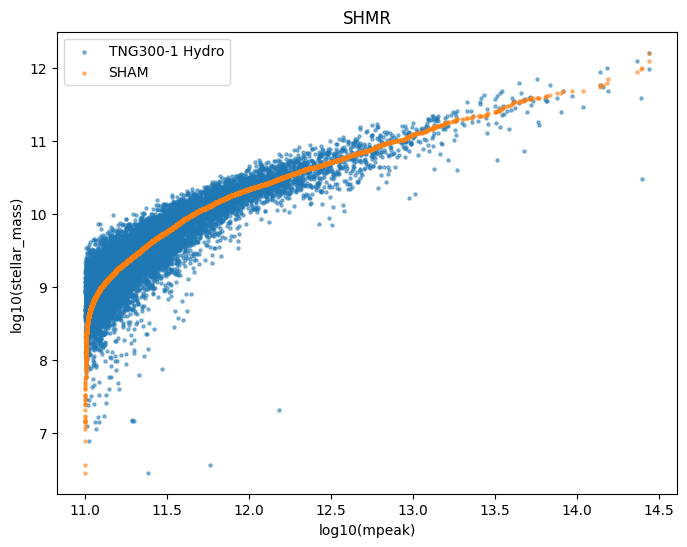

In [7]:
# SHMR
plt.figure(figsize=(8, 6))
plt.scatter(
    np.log10(hydro_high["mpeak"].data),
    np.log10(hydro_high["stellar_mass"].data),
    s=5,
    alpha=0.5,
    label="TNG300-1 Hydro",
)
plt.scatter(
    np.log10(hydro_high["mpeak"].data),
    logmstar_sham_high,
    s=5,
    alpha=0.5,
    label="SHAM",
)
plt.xlabel("log10(mpeak)")
plt.ylabel("log10(stellar_mass)")
plt.legend()
plt.title("SHMR")

In [8]:
x1 = np.log10(hydro_raw["stellar_mass"])
x2 = np.log10(hydro_raw["mpeak"])  # resolution
star_mask = (x1 > 9.5) & (x1 < 10.2) & (x2 > 11)
hydro_mstar_cut = hydro_raw[star_mask]

# get sham stellar mass bin predicted catalog
sham_mask = (logmstar_sham_high > 9.5) & (logmstar_sham_high < 10.2)
hydro_sham = hydro_high[sham_mask]


len(hydro_mstar_cut), len(hydro_sham)


(4050, 4050)

# CAM Prediction in SHAM bin

In [9]:
# CAM prediction for color
color_cam_pred = qt(hydro_sham["z12"].data, hydro_mstar_cut["color"])
color_cam_pred.shape

(4050,)

In [10]:
ns = np.linspace(0, 1, 11)[1:-1]
ns

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [11]:
# NOTE: can only train multicam on mpeak mass bin
_x = np.log10(hydro_raw["mpeak"])
mask = (_x > 11) & (_x < 12)
hydro_mpeak = hydro_raw[mask]

x_train = get_an_from_mpeak_mah(hydro_mpeak["mpeak_mah"], scales=scales, ns=ns)
y_train = hydro_mpeak["color"].reshape(-1, 1)

# but we want to apply on SHAM bin
x_test = get_an_from_mpeak_mah(hydro_sham["mpeak_mah"], scales=scales, ns=ns)

# and reproduce the color distribution in the true stellar mass bin!
y_true = hydro_mstar_cut["color"].reshape(-1, 1)


In [12]:
model = MultiCamSampling(len(ns), 1)
model.fit(x_train, y_train)

In [13]:
color_multicam_pred = model.sample(x_test, y_target=y_true, seed=41, no_scatter=True)[
    :, 0
]
color_multicam_pred.shape

(4050,)

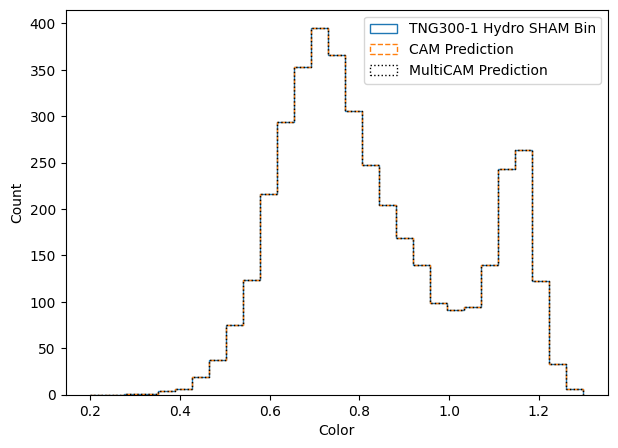

In [14]:
# histogram of color distribution
plt.figure(figsize=(7, 5))
bins = np.linspace(0.2, 1.3, 30)
plt.hist(
    hydro_mstar_cut["color"].data,
    bins=bins,
    histtype="step",
    label="TNG300-1 Hydro SHAM Bin",
)
plt.hist(color_cam_pred, bins=bins, histtype="step", ls="--", label="CAM Prediction")
plt.hist(
    color_multicam_pred,
    bins=bins,
    histtype="step",
    ls=":",
    label="MultiCAM Prediction",
    color="k",
)
plt.xlabel("Color")
plt.ylabel("Count")
plt.legend()

In [15]:
# spearmanr for color in SHAM bin
# multicam is low because random sample
(
    spearmanr(color_cam_pred, hydro_sham["color"].data).statistic,
    spearmanr(color_multicam_pred, hydro_sham["color"].data).statistic,
)

(np.float64(0.6377055965650519), np.float64(0.7099791091380907))

## Clustering predictions

In [16]:
# sham bin and color prediction of multicam is better so better color split clustering no?

In [17]:
Lbox = 110.7 * TNG_H  # TNG box size in Mpc /h
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(lbox=Lbox, n_randoms=10_000, rng=42)

randoms.shape

(10000, 3)

In [18]:
true_color = hydro_mstar_cut["color"]
red_true = hydro_mstar_cut[true_color > COLOR_CUT]
blue_true = hydro_mstar_cut[true_color <= COLOR_CUT]

multicam_red_pred = hydro_sham[color_multicam_pred > COLOR_CUT]
multicam_blue_pred = hydro_sham[color_multicam_pred <= COLOR_CUT]

In [19]:
(
    len(red_true),
    len(multicam_red_pred),
    len(blue_true),
    len(multicam_blue_pred),
)

(981, 981, 3069, 3069)

In [20]:
xyz_red = return_xyz_formatted_array(
    red_true["x"].data, red_true["y"].data, red_true["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_true["x"].data, blue_true["y"].data, blue_true["z"].data
)


xi_red_true = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_true = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [21]:
xyz_red = return_xyz_formatted_array(
    multicam_red_pred["x"].data,
    multicam_red_pred["y"].data,
    multicam_red_pred["z"].data,
)
xyz_blue = return_xyz_formatted_array(
    multicam_blue_pred["x"].data,
    multicam_blue_pred["y"].data,
    multicam_blue_pred["z"].data,
)


xi_red_multicam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_multicam = tpcf(
    xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max"
)


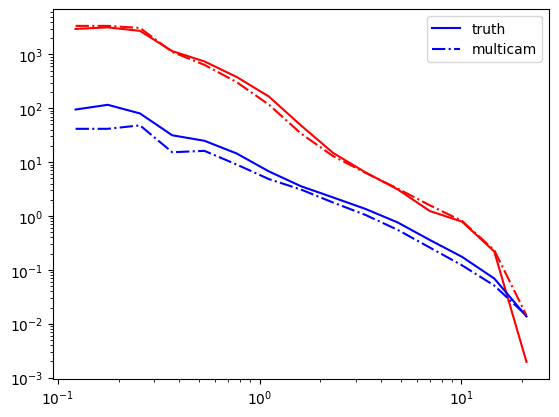

In [22]:
plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b", label="truth")


plt.loglog(rbin_centers, xi_red_multicam, c="r", ls="-.")
plt.loglog(rbin_centers, xi_blue_multicam, c="b", ls="-.", label="multicam")

plt.legend()

In [23]:
# colorless clustering
xyz = return_xyz_formatted_array(
    hydro_mstar_cut["x"].data, hydro_mstar_cut["y"].data, hydro_mstar_cut["z"].data
)
xi_true = tpcf(xyz, rbins, randoms=randoms, period=Lbox, num_threads="max")

xyz = return_xyz_formatted_array(
    hydro_sham["x"].data, hydro_sham["y"].data, hydro_sham["z"].data
)
xi_sham = tpcf(xyz, rbins, randoms=randoms, period=Lbox, num_threads="max")


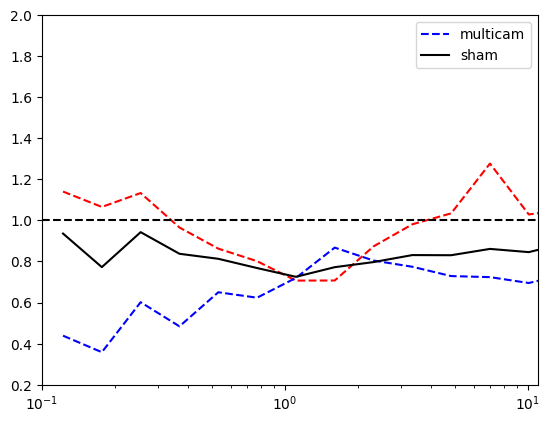

In [24]:
plt.semilogx(rbin_centers, xi_red_multicam / xi_red_true, c="r", ls="--")
plt.semilogx(
    rbin_centers, xi_blue_multicam / xi_blue_true, c="b", ls="--", label="multicam"
)
plt.semilogx(
    rbin_centers, xi_sham / xi_true, c="k", ls="-", label="sham"
)  # colorless clustering

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

plt.legend()

In [45]:
# they both up and down with respect to sham line, so is one really better than the other?
# maybe it's all statistical noise so shouldn't read into this trend too much?
# NOTE: color prediction even though it's better CAN'T correc the bias in the black prediction!
# also not ehow red/blue need to "cancel" each other by definition (weighted by true number of objects in each)

## Repeat ten times with MultiCAM random sample

In [ ]:
from tqdm import tqdm

from numpy import ndarray


def sample_clustering_multicam(
    model,
    *,
    sham_cat,
    n_samples: int,
    y_target: ndarray,
    randoms: ndarray,
    rbins: ndarray,
    Lbox: float,
):
    samples = []
    for ii in tqdm(range(n_samples)):
        # get color sample
        color = model.sample(x_test, y_target=y_target, seed=42 + ii, no_scatter=False)[
            :, 0
        ]

        # clustering
        red_pred = sham_cat[color > COLOR_CUT]
        blue_pred = sham_cat[color <= COLOR_CUT]

        xyz_red = return_xyz_formatted_array(
            red_pred["x"].data, red_pred["y"].data, red_pred["z"].data
        )
        xyz_blue = return_xyz_formatted_array(
            blue_pred["x"].data, blue_pred["y"].data, blue_pred["z"].data
        )

        xi_red = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")
        xi_blue = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")

        samples.append((xi_red, xi_blue))

    return np.array(samples)

In [ ]:
# xi_samples = sample_clustering_multicam(
#     model,
#     sham_cat=hydro_sham,
#     n_samples=20,
#     y_target=y_true,
#     randoms=randoms,
#     rbins=rbins,
#     Lbox=Lbox,
# )

100%|██████████| 20/20 [07:41<00:00, 23.05s/it]


In [ ]:
# # load and check they are the same
# data = np.load("multicam_clustering_samples.npz", allow_pickle=True)
# xi_samples_loaded = data["xi_samples"]
# rbin_centers_loaded = data["rbin_centers"]
# xi_red_true_loaded = data["xi_red_true"]
# xi_blue_true_loaded = data["xi_blue_true"]

# assert np.allclose(xi_samples, xi_samples_loaded)
# assert np.allclose(rbin_centers, rbin_centers_loaded)
# assert np.allclose(xi_red_true, xi_red_true_loaded)
# assert np.allclose(xi_blue_true, xi_blue_true_loaded)

In [25]:
xi_samples = np.load("multicam_clustering_samples.npz", allow_pickle=True)["xi_samples"]

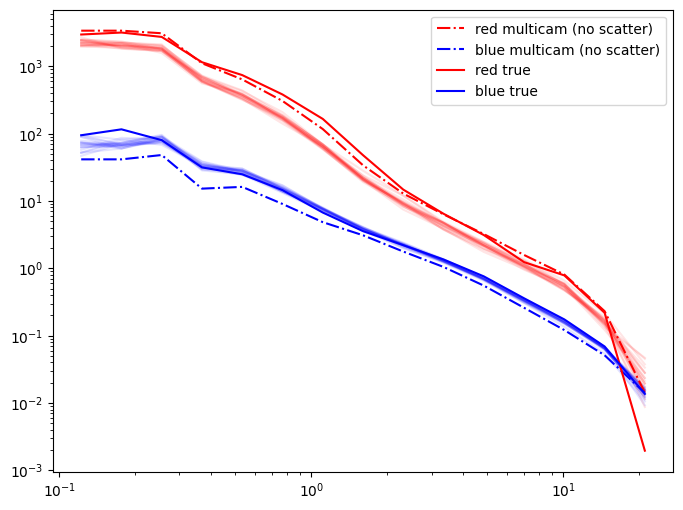

In [29]:
# plot clustering samples along with truth in light colors
plt.figure(figsize=(8, 6))
for xi_red, xi_blue in xi_samples:
    plt.loglog(rbin_centers, xi_red, c="r", alpha=0.1, ls="-")
    plt.loglog(rbin_centers, xi_blue, c="b", alpha=0.1, ls="-")

# multicam no samlping
plt.loglog(
    rbin_centers, xi_red_multicam, c="r", ls="-.", label="red multicam (no scatter)"
)
plt.loglog(
    rbin_centers, xi_blue_multicam, c="b", ls="-.", label="blue multicam (no scatter)"
)


plt.loglog(rbin_centers, xi_red_true, c="r", ls="-", label="red true")
plt.loglog(rbin_centers, xi_blue_true, c="b", ls="-", label="blue true")
plt.legend()


In [ ]:
# # save clustering samples for later
# np.savez(
#     "multicam_clustering_samples.npz",
#     xi_samples=xi_samples,
#     rbin_centers=rbin_centers,
#     xi_red_true=xi_red_true,
#     xi_blue_true=xi_blue_true,
# )